In [4]:
# 데이터 전처리, 데이터 증강
import matplotlib.pyplot as plt
from torchvision.datasets.cifar import CIFAR10
from torchvision.transforms import ToTensor

# 데이터셋 불러오기
training_dataset = CIFAR10 (
    root = './',
    train = True,
    download=True,
    transform=ToTensor()
)


test_dataset = CIFAR10 (
    root = './',
    train = False,
    download=True,
    transform=ToTensor()
)

# ToTensor()는 이미지를 PyTorch 텐서로 변환해주는 아주 기본적인 전처리예요.
# CIFAR10 같은 이미지는 원래 PIL 이미지 또는 numpy 배열 형태로 되어 있어요.
# ToTensor()를 적용하면:
# 이미지 데이터를 [H, W, C] → [C, H, W] 형태로 바꿔줘요. (PyTorch는 채널 우선)
# 픽셀 값 범위를 0~255 (정수) → 0.0~1.0 (float)으로 정규화


Files already downloaded and verified
Files already downloaded and verified


In [ ]:
training_dataset[0] # 결과 --> tuple (이미지데이터, 이미지라벨)

training_dataset[0][0] # --> 이미지데이터
training_dataset[0][1] # --> 이미지 라벨

training_dataset[0][0].size() #--> torch.Size([3, 32, 32]) --> [채널, 높이, 너비] (pyTorch) 

# matplot 은 [높이, 너비, 채널]로 데이터 위치를 변경해야함.

# training_dataset[0][0].view(32,32,3).size()
  # --> 이렇게하면, 데이터 메모리를 재배치하게 되기 때문에, 데이터가 뒤섞여서 잘못나옴

# img.permute (C,H,W): 0 1 2 --> 1 2 0 (H,W,C) 데이터의 위치만 변경해줌 

torch.Size([3, 32, 32])

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# 하기 이미지셀 관련 커널 충돌로 인해 추가함

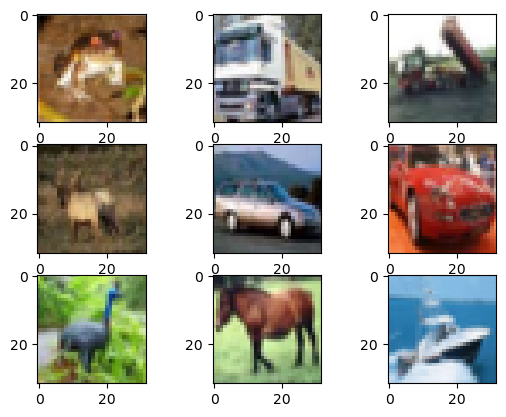

In [6]:
for i in range(9):
    img, label = training_dataset[i]
    plt.subplot(3,3,i+1)
    # plt.imshow(training_dataset[i][0].view(32,32,3)) # 하면 안됨??
    plt.imshow (img.permute(1,2,0))  #(C,H,W): 0 1 2 -- 1 2 0 (H,W,C) 데이터 위치만 변경
plt.show()




Files already downloaded and verified
Files already downloaded and verified


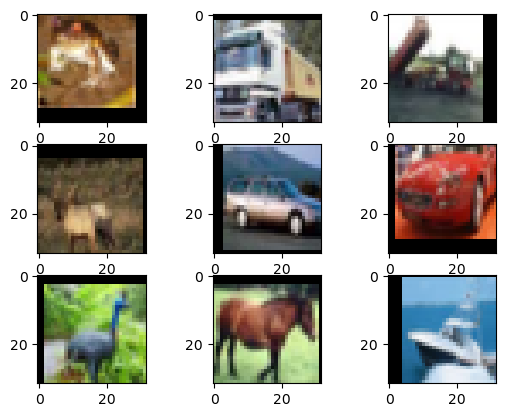

In [7]:
# 데이터 증강
    # 딥러닝 모델은 훈련 데이터를 계속 보면서 “패턴”을 배워요.
    # 그런데 그림을 외워버리면, 새로운 이미지를 보면 헷갈려요.
    # 예를 들어:
    # 고양이 사진이 항상 “왼쪽을 보고” 있으면, 오른쪽을 보는 고양이는 못 알아봐요 😅
    # 이게 바로 **과적합(overfitting)**이에요.
    # --> 그래서 일부러 이미지를 살짝씩 바꿔줌
    # --> 크롭핑과 뒤집기 ---> 모델에게 '이게 왼쪽을 보든 오른쪽을 보든 그래도 고양이야' 라고 가르침
    # --> 모델이 외우지 않고 "특징"을 진짜로 학습


# 크롭핑과 뒤집기 추가 
    # 크롭 : 테두리 자르기
    # horizontal :  좌우 반전
# 이미지는 노이즈가 있으면 완벽한 데이터에만 익숙해지지 않도록 막아줘서, 적당한 노이즈는 도움이 됨


import torchvision.transforms as T 
import matplotlib.pyplot as plt
from torchvision.datasets.cifar import CIFAR10
from torchvision.transforms import Compose
from torchvision.transforms import RandomHorizontalFlip, RandomCrop

transform = Compose([
    T.ToTensor(),
    RandomCrop( (32,32), padding=4),
    RandomHorizontalFlip(p=0.5),
])

training_dataset = CIFAR10 (
    root = './',
    train = True,
    download=True,
    transform=transform
)


test_dataset = CIFAR10 (
    root = './',
    train = False,
    download=True,
    transform=transform
)

for i in range(9):
    img, label = training_dataset[i]
    plt.subplot(3,3,i+1)
    plt.imshow (img.permute(1,2,0))  #(C,H,W): 0 1 2 -- 1 2 0 (H,W,C) 데이터 위치만 변경
plt.show()

Files already downloaded and verified
Files already downloaded and verified


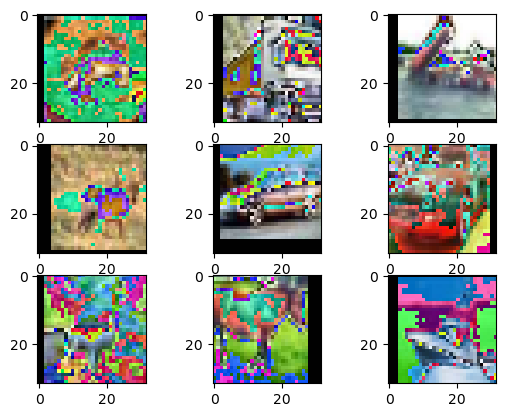

In [ ]:
# 데이터 전처리에 정규화 추가
 # 정규화: 데이터의 값 범위를 일정하게 맞춰줌
 # 픽셀값이 들쭉날쭉 하므로 --> ToTensor() 이미지를 0~1 사이 값으로 
 # CNN --> -1 ~ 1 범위에서 안정적으로 학습

import torchvision.transforms as T 
from torchvision.transforms import Compose
from torchvision.transforms import RandomHorizontalFlip, RandomCrop, Normalize

transform = Compose([
    T.ToPILImage(),            # numpy -> PIL 이미지로 변환 (crop, flip 적용 가능하게)
    RandomCrop( (32,32), padding=4),    # 데이터 증강 : 크롭
    RandomHorizontalFlip(p=0.5),        # 데이터 증강 : 좌우반전
    T.ToTensor(),                       # PIL -> Tensor 0~1로 정규화 
    Normalize( (0.5, 0.5, 0.5), (0.5,0.5,0.5)),   # 정규화 : To Tensor 0~1 --> Normarlize를 통해 -1 ~ 1로 
    T.ToPILImage()   # --> 학습용에서는 삭제할 것. Tensor로 유지해야하므로.
        # T.ToPILImage() --> 하기 matplotlib plt.show() 실행을 위해서 기재함.
])


training_dataset = CIFAR10 (
    root = './',
    train = True,
    download=True,
    transform=transform
)


test_dataset = CIFAR10 (
    root = './',
    train = False,
    download=True,
    transform=transform
)

for i in range(9):
    # img, label = training_dataset[i]
    plt.subplot(3,3,i+1)
    # plt.imshow (img.permute(1,2,0))  #(C,H,W): 0 1 2 -- 1 2 0 (H,W,C) 데이터 위치만 변경
    plt.imshow(transform(training_dataset.data[i]))
plt.show()

### VGG
https://wikidocs.net/164796
- VGG : Visual Geometry Group
- VGG16 Architecture
- VGG 이름의 숫자 16은 16계층 심층신경망(VGGnet)이라는 사실을 나타냅니다
- 사진을 분류하는 딥러닝 모델
- 최신모델(ResNet)에 비해서 느리지만, "기본기 교과서 같은 모델"

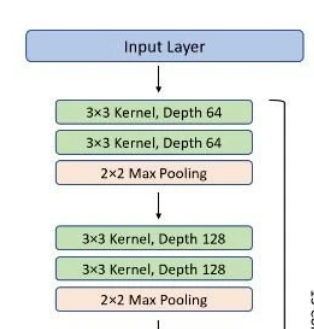

#### >>> CNN (Convolutional Neural Network) 이미지를 인식하는 딥러닝 모델

https://mijeongban.medium.com/%EB%94%A5%EB%9F%AC%EB%8B%9D-%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D-cnn-convolutional-neural-networks-%EC%89%BD%EA%B2%8C-%EC%9D%B4%ED%95%B4%ED%95%98%EA%B8%B0-836869f88375

In [12]:
#######실행1

import torch.nn as nn
class BasicBlock(nn.Module):
    def __init__ (self, int_channels, out_channels, hidden_dim):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(int_channels, hidden_dim, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(hidden_dim, out_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2)
    def forward(self, x) :   # Conv1 → ReLU → Conv2 → ReLU → Pool
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        out = self.pool(x)
        return out

In [13]:
#######실행2

import torch
class CNN(nn.Module):
    def __init__ (self, num_class):
        super(CNN, self).__init__()
        
        #상기 셀에 BasicBlock에 정의된 순서 int_channels, out_channels, hidden_dim  
        self.block1 = BasicBlock(3, 64, 64)   # c c p :  (3,32,32) --> (64, 32, 32) --> (64, 32,32) --> (64, 16, 16)
        self.block2 = BasicBlock(64, 128, 128) # --> (128, 16, 16) --> (128, 16, 16) --> (128, 8, 8)

        # 분류기 (FC = Fully Connected layer = 완전연결층)
        self.fc1 = nn.Linear ( 128*8*8,2048)     
        self.fc2 = nn.Linear (2048, 256)
        self.fc3 = nn.Linear (256, num_class)
        self.relu = nn.ReLU()

    def forward (self, x):
        x= self.block1(x)
        x= self.block2(x)
        # (-1,128*8*)
        x=torch.flatten(x,start_dim=1) # 1d로 펴주기. 데이터갯수는 두고..???
        x= self.relu (self.fc1(x)) # fc층도 선형연산이므로, 비선형성 없이 여러 FC층을 쌓으면 한층짜리 선형모델이므로, ReLU를 넣어 복잡한 패턴을 학습하도록.
        x= self.relu (self.fc2(x))
        out= self.fc3(x) # 최종 출력층은 클래스별 점수를 출력 ReLU넣으면 음수값이 잘리기 때문.
        return out 


<span style="font-size:11px">

- 🧩 BasicBlock(3, 64, 64) — block1 분석

<br> self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
<br> self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
<br> self.pool = nn.MaxPool2d(2)

| 단계           | 연산      | 출력 형태        | 설명                      |
| ------------ | ------- | ------------ | ----------------------- |
| 입력           | —       | (3, 32, 32)  | RGB 이미지                 |
| conv1        | 3 → 64  | (64, 32, 32) | 채널 수 3 → 64, 이미지 크기는 유지 |
| ReLU         | —       | (64, 32, 32) | 음수 제거                   |
| conv2        | 64 → 64 | (64, 32, 32) | 특징을 더 조합                |
| ReLU         | —       | (64, 32, 32) | 비선형성 추가                 |
| MaxPool(2×2) | —       | (64, 16, 16) | 이미지 절반 크기로 축소           |

- ✅ 결과:
    - 출력 → (64, 16, 16)
    - 이게 다음 블록(block2)의 입력이 됩니다.

- 🧩 BasicBlock(64, 128, 128) — block2 분석
    - self.conv1 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
    - self.conv2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
    - self.pool = nn.MaxPool2d(2)

| 단계           | 연산        | 출력 형태         | 설명         |
| ------------ | --------- | ------------- | ---------- |
| 입력           | —         | (64, 16, 16)  | block1의 결과 |
| conv1        | 64 → 128  | (128, 16, 16) | 채널 수 증가    |
| ReLU         | —         | (128, 16, 16) | 활성화        |
| conv2        | 128 → 128 | (128, 16, 16) | 복잡한 특징 추출  |
| ReLU         | —         | (128, 16, 16) | 비선형성       |
| MaxPool(2×2) | —         | (128, 8, 8)   | 크기 반으로 줄임  |


- ✅ 결과:
    - 출력 → (128, 8, 8)    
    - 이제 이걸 평평하게(Flatten) 펼쳐서 완전연결층(FC Layer)에 넣어요.

- 🧮 Flatten 과정
    - (128, 8, 8) → 128×8×8 = 8192

- 즉, 이미지 특징을 1차원 벡터로 쭉 펴서
- nn.Linear(8192, 2048) 이런 식으로 넣게 됩니다.


In [14]:
# 샘플데이터 생성해서 구조 확인하기 : for 문 등에서 수정하기 어려우므로 중간단계에서 확인할 것
X = torch.randn (4,3,32,32)
model = CNN(10)
model(X)

tensor([[ 0.0084, -0.0164,  0.0613,  0.0562,  0.0343, -0.0550,  0.0149,  0.0229,
         -0.0511, -0.0240],
        [ 0.0105, -0.0187,  0.0626,  0.0554,  0.0342, -0.0568,  0.0136,  0.0208,
         -0.0498, -0.0213],
        [ 0.0093, -0.0153,  0.0598,  0.0568,  0.0358, -0.0554,  0.0139,  0.0197,
         -0.0517, -0.0223],
        [ 0.0097, -0.0180,  0.0619,  0.0575,  0.0348, -0.0545,  0.0146,  0.0219,
         -0.0521, -0.0195]], grad_fn=<AddmmBackward0>)

In [16]:
#######실행3

# 데이터 증강
transform = Compose([
    RandomCrop( (32,32), padding=4),
    RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    # 데이터 정규화 Noarmalize (평균, 표준편차)
    Normalize( (0.5, 0.5, 0.5), (0.5,0.5,0.5))
])


# 데이터 셋
training_dataset = CIFAR10 (root = './', train = True, download=True, transform=transform)
test_dataset = CIFAR10 (root = './', train = False, download=True,transform=transform)
    # 테스트는 상기 데이터 증강 없이 ToTensor()만 하면 됨.


# 데이터 로더
    # 머신러닝 : 데이터가 작고 메모리에 다 올라갈 수 있어서 X_train, X_test로 모든데이터를 통째로 모델에 넣고 학습가능
    # 딥러닝 : 데이터가 크고 많아서 한번에 다 넣으면 메모리 부족 --> batch 단위로 나눠서 학습
from torch.utils.data.dataloader import DataLoader
train_loader = DataLoader(training_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = CNN(10)  # CIFAR-10 데이터셋의 클래스가 10개가 있기 때문에 CNN(10)이라고 기재
model.to(device)



Files already downloaded and verified
Files already downloaded and verified


CNN(
  (block1): BasicBlock(
    (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): BasicBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=8192, out_features=2048, bias=True)
  (fc2): Linear(in_features=2048, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
  (relu): ReLU()
)

In [ ]:
# model.fc3 를 통해서 레이어에 접근 및 변경이 가능함.
# model.fc3 = nn.Linear(in_features=256, out_features=2, bias=True)

In [29]:
%pip install torchsummary

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# 모델 layer에 통과한 후 output shape 확인
from torchsummary import summary
model = CNN(10)
summary(model, (3,32,32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
              ReLU-2           [-1, 64, 32, 32]               0
            Conv2d-3           [-1, 64, 32, 32]          36,928
              ReLU-4           [-1, 64, 32, 32]               0
         MaxPool2d-5           [-1, 64, 16, 16]               0
        BasicBlock-6           [-1, 64, 16, 16]               0
            Conv2d-7          [-1, 128, 16, 16]          73,856
              ReLU-8          [-1, 128, 16, 16]               0
            Conv2d-9          [-1, 128, 16, 16]         147,584
             ReLU-10          [-1, 128, 16, 16]               0
        MaxPool2d-11            [-1, 128, 8, 8]               0
       BasicBlock-12            [-1, 128, 8, 8]               0
           Linear-13                 [-1, 2048]      16,779,264
             ReLU-14                 [-

In [ ]:
# 학습에 참여하는 가중치 정보
for name, param in model.named_parameters():
    print(f'{name} {list(param.shape)}')

block1.conv1.weight [64, 3, 3, 3]
block1.conv1.bias [64]
block1.conv2.weight [64, 64, 3, 3]
block1.conv2.bias [64]
block2.conv1.weight [128, 64, 3, 3]
block2.conv1.bias [128]
block2.conv2.weight [128, 128, 3, 3]
block2.conv2.bias [128]
fc1.weight [2048, 8192]
fc1.bias [2048]
fc2.weight [256, 2048]
fc2.bias [256]
fc3.weight [10, 256]
fc3.bias [10]


In [18]:
#######실행4

# 하이퍼 파라미터
from torch.optim import Adam 
lr = 1e-3  #learning rate 학습률 (한번에 가중치를 얼마나 조금씩 바꿀지)
optimizer = Adam(model.parameters(), lr=lr)  # 가중치 조정
epochs = 5  #전체 데이터셋 5번 반복 학습


from tqdm import tqdm 
# 학습루프
for epoch in range(epochs):     # 데이터셋 전체를 반복 학습
    for data, label in tqdm(train_loader):    #배치 단위로 데이터 가져오기(DataLoader)
        optimizer.zero_grad()   # 기울기 초기화
        preds = model (data.to(device))  # 모델에 이미지 넣고 예측값 계산
        loss = nn.CrossEntropyLoss()(preds, label.to(device))  # 모델출력(preds)과 정답(label)비교 --> 차이로 loss 손실 계산 (숫자로만. 가중치없이)
        loss.backward()  #손실을 줄이기 위해 가중치별 변화량 계산 (모델이 어디서 얼마나 잘못했는지 각 가중치에 신호. conv1필터, fc1가중치 등)
        optimizer.step()  #상기 계산된 가중치를 업데이트
        
    if (epoch+1)%10==0:
        print(f'epoch {epoch+1}, loss {loss.item()}')

torch.save(model.state_dict(), 'cifar.pth')  #torch에는 모델 저장 기능이 있음 / 가중치만 저장되어있음./ 모델구조는 저장되어 있지 않음. (모델+가중치 저장되는 것도 있음. 용량 많이 차지함)
        


100%|██████████| 196/196 [04:09<00:00,  1.27s/it]


In [20]:
#######실행5
# 평가
    # load_state_dict : 모델에 저장된 가중치를 불러옴.
model.load_state_dict(torch.load('cifar.pth', map_location=device, weights_only=True))


# 예측
num_corr=0
with torch.no_grad():  # 평가 단계라서, 학습X 
    for data, label in test_loader :
        output = model(data.to(device))  # 모델이 예측한 값 계산
        preds = output.data.max(1)[1]       # 각 이미지에서 가장 높은 점수 --> 예측 클래스
        corr = preds.eq(label.to(device).data).sum().item()  # 맞춘 개수 계산
        num_corr += corr
    print(f'Accuracy : {num_corr/len(test_dataset)}')   # 정확도 계산 --> 전체 맞춘 개수 / 데이터 갯수

Accuracy : 0.7404


======================================

======================== DJ 🔹 딥러닝 CNN 전체 코드 정리 (CIFAR-10 기준)

In [ ]:
# ============================
# 1️⃣ 필요한 라이브러리 불러오기
# ============================
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10
from torchvision.transforms import Compose, RandomCrop, RandomHorizontalFlip, ToTensor, Normalize
from torch.optim import Adam
from tqdm import tqdm

# ============================
# 2️⃣ BasicBlock 정의
# ============================
class BasicBlock(nn.Module):
    def __init__(self, int_channels, out_channels, hidden_dim):
        super(BasicBlock, self).__init__()
        # 1번째 convolution
        self.conv1 = nn.Conv2d(int_channels, hidden_dim, kernel_size=3, padding=1)  
        # 2번째 convolution
        self.conv2 = nn.Conv2d(hidden_dim, out_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2)  # MaxPool: 이미지 크기를 절반으로 줄임, 가장 큰 값만 선택^1

    def forward(self, x):
        x = self.relu(self.conv1(x))  # conv1 → relu
        x = self.relu(self.conv2(x))  # conv2 → relu
        out = self.pool(x)            # pooling → 크기 절반
        return out

# ============================
# 3️⃣ CNN 모델 정의
# ============================
class CNN(nn.Module):
    def __init__(self, num_class):
        super(CNN, self).__init__()
        # feature extractor (conv + pool)
        self.block1 = BasicBlock(3, 64, 64)    # 입력 이미지 (3,32,32) → 출력 (64,16,16)^2
        self.block2 = BasicBlock(64, 128, 128) # 입력 (64,16,16) → 출력 (128,8,8)^3

        # classifier (FC층)
        self.fc1 = nn.Linear(128*8*8, 2048)  # flatten 후 연결
        self.fc2 = nn.Linear(2048, 256)
        self.fc3 = nn.Linear(256, num_class) # 최종 클래스 출력
        self.relu = nn.ReLU()                 # fc층에도 ReLU 적용^4

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = torch.flatten(x, start_dim=1)     # (C,H,W) → 1차원 벡터
        x = self.relu(self.fc1(x))            # fc1 → relu
        x = self.relu(self.fc2(x))            # fc2 → relu
        out = self.fc3(x)                     # fc3 → 최종 출력 (Softmax는 평가 단계에서^5)
        return out

# ============================
# 4️⃣ 데이터 준비
# ============================
# 데이터 증강 (augmentation)
transform = Compose([
    RandomCrop((32,32), padding=4),      # 이미지 랜덤 잘라내기
    RandomHorizontalFlip(p=0.5),         # 좌우 뒤집기
    ToTensor(),
    Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))  # 정규화
])

# CIFAR-10 데이터셋
training_dataset = CIFAR10(root='./', train=True, download=True, transform=transform)
test_dataset = CIFAR10(root='./', train=False, download=True, transform=transform)  # 테스트는 증강 X

# 데이터 로더
train_loader = DataLoader(training_dataset, batch_size=256, shuffle=True)   # 학습용
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)       # 평가용

# ============================
# 5️⃣ 모델 및 학습 설정
# ============================
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = CNN(10)        # CIFAR-10 → 클래스 10개
model.to(device)

lr = 1e-3
optimizer = Adam(model.parameters(), lr=lr)
epochs = 5

# ============================
# 6️⃣ 학습 루프
# ============================
for epoch in range(epochs):
    for data, label in tqdm(train_loader):
        optimizer.zero_grad()                    # 이전 gradient 초기화
        preds = model(data.to(device))           # 모델 예측
        loss = nn.CrossEntropyLoss()(preds, label.to(device))  # 손실 계산^6
        loss.backward()                          # 역전파 → gradient 계산^7
        optimizer.step()                         # 가중치 업데이트^8
        
    if (epoch+1) % 10 == 0:
        print(f'epoch {epoch+1}, loss {loss.item()}')

# 학습 완료 후 가중치 저장
torch.save(model.state_dict(), 'cifar.pth')  # 모델 가중치만 저장^9

# ============================
# 7️⃣ 평가
# ============================
# 저장된 가중치를 불러오기 (필요 시)
model.load_state_dict(torch.load('cifar.pth', map_location=device, weights_only=True))  # 학습 후 바로 평가라면 생략 가능^10

num_corr = 0
with torch.no_grad():  # 평가 단계에서는 gradient 계산 X
    for data, label in test_loader:
        output = model(data.to(device))
        preds = output.data.max(1)[1]                # 가장 높은 점수 선택 → 예측 클래스
        corr = preds.eq(label.to(device).data).sum().item()
        num_corr += corr                             # 맞춘 개수 누적^11

print(f'Accuracy : {num_corr / len(test_dataset)}')   # 전체 데이터 기준 정확도 계산


<span style="font-size:12px">

📌 각주 설명

- **MaxPool** : 입력 이미지에서 2×2 영역마다 가장 큰 값만 선택 → 이미지 크기 절반, 중요한 특징만 남김
- **block1 출력** : 입력 (3,32,32) → conv1→conv2→pool → (64,16,16)
- **block2 출력** : 입력 (64,16,16) → conv1→conv2→pool → (128,8,8)
- **FC층 ReLU** : fc1, fc2에 ReLU 적용 → 비선형성 추가, 패턴 학습 가능
- **Softmax** : 마지막 fc3는 Softmax 적용 안 함 → 평가 시 필요하면 `torch.softmax()` 사용
- **loss = nn.CrossEntropyLoss()** : 예측과 정답 비교 → 손실 계산
- **loss.backward()** : 손실을 줄이기 위해 가중치별 gradient 계산
- **optimizer.step()** : gradient에 따라 실제 가중치 업데이트
- **torch.save()** : 모델 가중치만 저장, 구조는 저장되지 않음
- **load_state_dict()** : 저장된 가중치를 모델에 적용 → 학습 후 바로 평가라면 생략 가능
- **num_corr += corr** : 테스트 배치에서 맞춘 개수를 누적해야 정확도 계산 가능 (`=+` 오타 주의)
